In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [92]:
df=pd.read_csv('googleplaystore.csv')
df_copy=df
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [93]:
df.shape

(10841, 13)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [95]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## Data Cleaning

In [96]:
#Handling Size feature
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size'].unique()

array(['19000', '14000', '8.7000', '25000', '2.8000', '5.6000', '29000',
       '33000', '3.1000', '28000', '12000', '20000', '21000', '37000',
       '2.7000', '5.5000', '17000', '39000', '31000', '4.2000', '7.0000',
       '23000', '6.0000', '6.1000', '4.6000', '9.2000', '5.2000', '11000',
       '24000', nan, '9.4000', '15000', '10000', '1.2000', '26000',
       '8.0000', '7.9000', '56000', '57000', '35000', '54000', '201',
       '3.6000', '5.7000', '8.6000', '2.4000', '27000', '2.5000', '16000',
       '3.4000', '8.9000', '3.9000', '2.9000', '38000', '32000', '5.4000',
       '18000', '1.1000', '2.2000', '4.5000', '9.8000', '52000', '9.0000',
       '6.7000', '30000', '2.6000', '7.1000', '3.7000', '22000', '7.4000',
       '6.4000', '3.2000', '8.2000', '9.9000', '4.9000', '9.5000',
       '5.0000', '5.9000', '13000', '73000', '6.8000', '3.5000', '4.0000',
       '2.3000', '7.2000', '2.1000', '42000', '7.3000', '9.1000', '55000',
       '23', '6.5000', '1.5000', '7.5000', '51000', 

In [97]:
ele_to_rem=[',','.','+']
cols=['Size']
for col in cols:
    for item in ele_to_rem:
        df_copy[col]=df_copy[col].str.replace(item,'')

In [98]:
df_copy['Size']=df_copy['Size'].astype('float')

In [101]:
#Handling Reviews feature
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [100]:
df_copy=df_copy.drop(index=10472)

In [109]:
df_copy['Reviews']=df_copy['Reviews'].astype('int')
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.2+ MB


In [110]:
#Handling Rating feature
df_copy['Rating']=df_copy['Rating'].fillna(df_copy['Rating'].mean())
df_copy['Rating']=df_copy['Rating'].astype('float')


0        4.100000
1        3.900000
2        4.700000
3        4.500000
4        4.300000
           ...   
10836    4.500000
10837    5.000000
10838    4.191757
10839    4.500000
10840    4.500000
Name: Rating, Length: 10840, dtype: float64

In [114]:
#Handling Install feature
ele_to_rem=[',','.','+']
cols=['Installs']
for col in cols:
    for item in ele_to_rem:
        df_copy[col]=df_copy[col].str.replace(item,'')
df_copy['Installs'].unique()   

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [116]:
#Handling Last_Updated feature
df_copy['Last Updated']

0         January 7, 2018
1        January 15, 2018
2          August 1, 2018
3            June 8, 2018
4           June 20, 2018
               ...       
10836       July 25, 2017
10837        July 6, 2018
10838    January 20, 2017
10839    January 19, 2015
10840       July 25, 2018
Name: Last Updated, Length: 10840, dtype: object

In [117]:
df_copy['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [129]:
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159,19000.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.900000,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.700000,87510,87000.0,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644,25000.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967,28000.0,100000,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.500000,38,53000.0,5000,Free,0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.000000,4,36000.0,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,4.191757,3,95000.0,1000,Free,0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.500000,114,NaN,1000,Free,0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,19,1,2015


In [130]:
df_copy.drop('Last Updated',axis=1)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Day,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159,19000.0,10000,Free,0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.900000,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.700000,87510,87000.0,5000000,Free,0,Everyone,Art & Design,1.2.4,4.0.3 and up,1,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644,25000.0,50000000,Free,0,Teen,Art & Design,Varies with device,4.2 and up,8,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967,28000.0,100000,Free,0,Everyone,Art & Design;Creativity,1.1,4.4 and up,20,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.500000,38,53000.0,5000,Free,0,Everyone,Education,1.48,4.1 and up,25,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.000000,4,36000.0,100,Free,0,Everyone,Education,1.0,4.1 and up,6,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,4.191757,3,95000.0,1000,Free,0,Everyone,Medical,1.0,2.2 and up,20,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.500000,114,NaN,1000,Free,0,Mature 17+,Books & Reference,Varies with device,Varies with device,19,19,1,2015


In [132]:
df_copy.to_csv('data/cleaned_google_data.csv')

## EDA

In [149]:
df_copy[df_copy.duplicated('App')].shape

(0, 17)

## observation
the dataset have duplicate value

In [146]:
df_copy=df_copy.drop_duplicates(subset='App',keep='first')

In [184]:
df_copy.shape

(9659, 17)

In [229]:
categorical_feature=[col for col in df_copy.columns if df_copy[col].dtype =='O']
numerical_feature=[col for col in df_copy.columns if df_copy[col].dtype !='O']
print('we have {} categorical data : {}'.format(len(categorical_feature),categorical_feature))
print('we have {} categorical data : {}'.format(len(numerical_feature),numerical_feature))

we have 9 categorical data : ['App', 'Category', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']
we have 8 categorical data : ['Rating', 'Reviews', 'Size', 'Last Updated', 'Last Updated Day', 'Day', 'Month', 'Year']


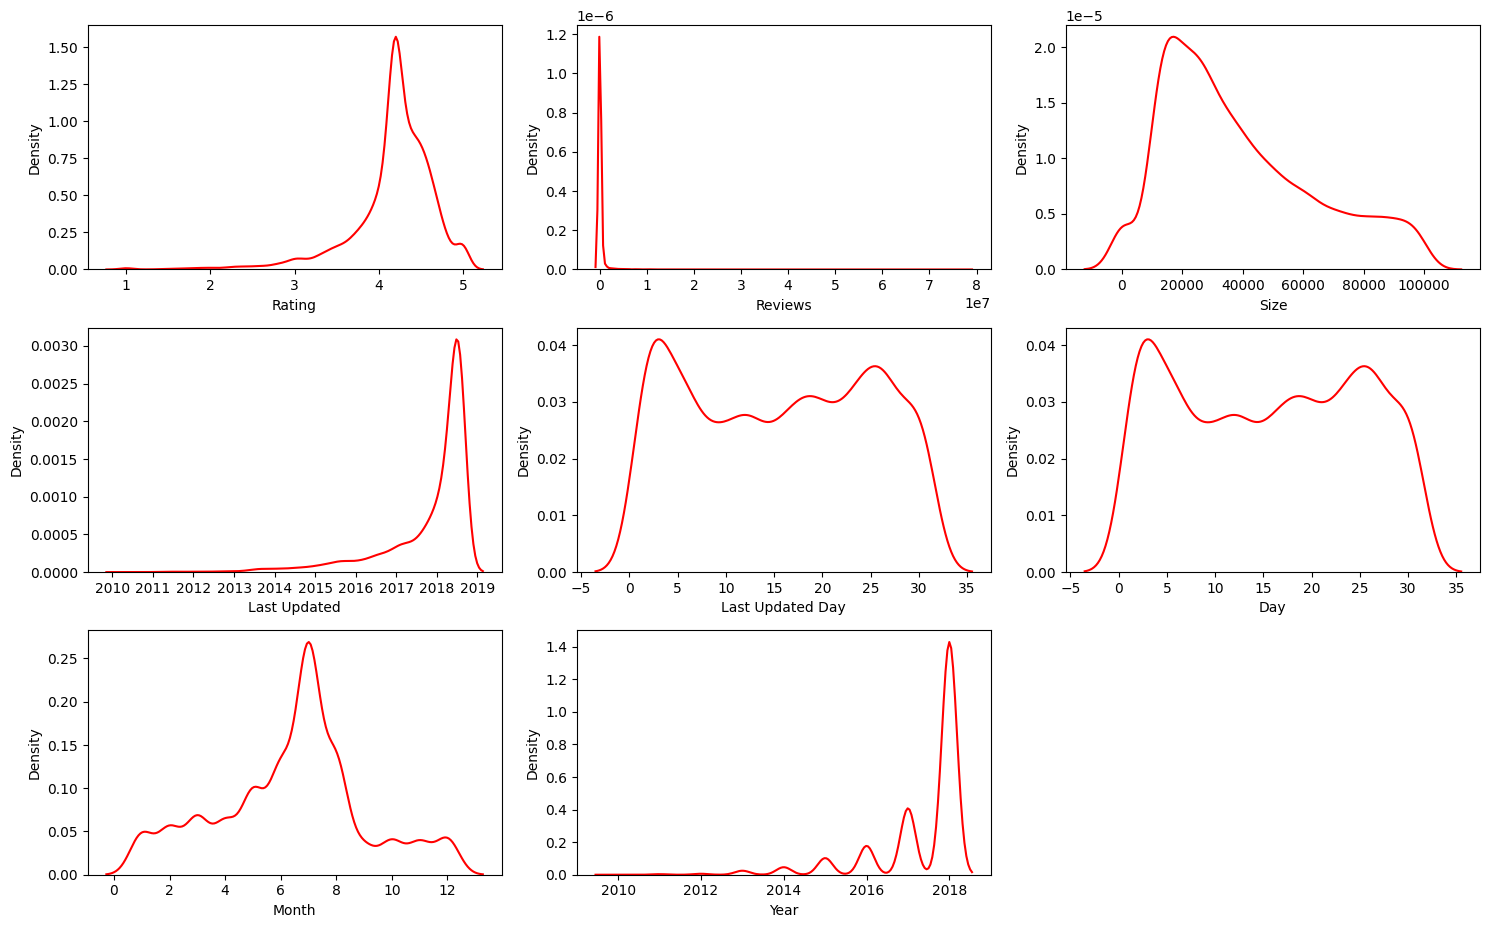

In [241]:
plt.figure(figsize=(15,15))
for i in range(len(numerical_feature)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numerical_feature[i]],color='red')
    plt.tight_layout()

In [186]:
for col in categorical_feature:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('\n the number of different values in {} --> {}'.format(col,len(df[col].unique())))
    print("---------------------------------------")

App
Photo Editor & Candy Camera & Grid & ScrapBook    0.010353
Tic Tac CK                                        0.010353
INFAMY RO                                         0.010353
CK Call NEW                                       0.010353
Ck Coif                                           0.010353
                                                    ...   
Bike Race Free - Top Motorcycle Racing Games      0.010353
Dance School Stories - Dance Dreams Come True     0.010353
3D Bowling                                        0.010353
Mind Games Pro                                    0.010353
iHoroscope - 2018 Daily Horoscope & Astrology     0.010353
Name: proportion, Length: 9659, dtype: float64

 the number of different values in App --> 9660
---------------------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PROD

([<matplotlib.patches.Wedge at 0x136faed50>,
 [Text(0.9252221906016734, 0.5949486515811603, 'FAMILY'),
  Text(0.10582595621596219, 1.0948976513770488, 'GAME'),
  Text(-0.5074247195056243, 0.9759713899672667, 'TOOLS'),
  Text(-0.8321305926793034, 0.7194155104855547, 'MEDICAL'),
  Text(-0.9926802588839505, 0.4739049520970352, 'BUSINESS'),
  Text(-1.0803639818334383, 0.20691463640109742, 'PRODUCTIVITY'),
  Text(-1.0987730683345494, -0.05193981423416898, 'PERSONALIZATION'),
  Text(-1.0592687745321803, -0.2965630848590114, 'COMMUNICATION'),
  Text(-0.9672294787945032, -0.5238961112194994, 'SPORTS'),
  Text(-0.8281567428947576, -0.7239864703141534, 'LIFESTYLE'),
  Text(-0.6530708834099519, -0.8851544617986995, 'FINANCE'),
  Text(-0.45932754911575857, -0.9995089807617091, 'HEALTH_AND_FITNESS'),
  Text(-0.2559917243967501, -1.0697982225823608, 'PHOTOGRAPHY'),
  Text(-0.05751107088453364, -1.0984955515275037, 'SOCIAL'),
  Text(0.1264300614297566, -1.0927101351991149, 'NEWS_AND_MAGAZINES'),
  Te

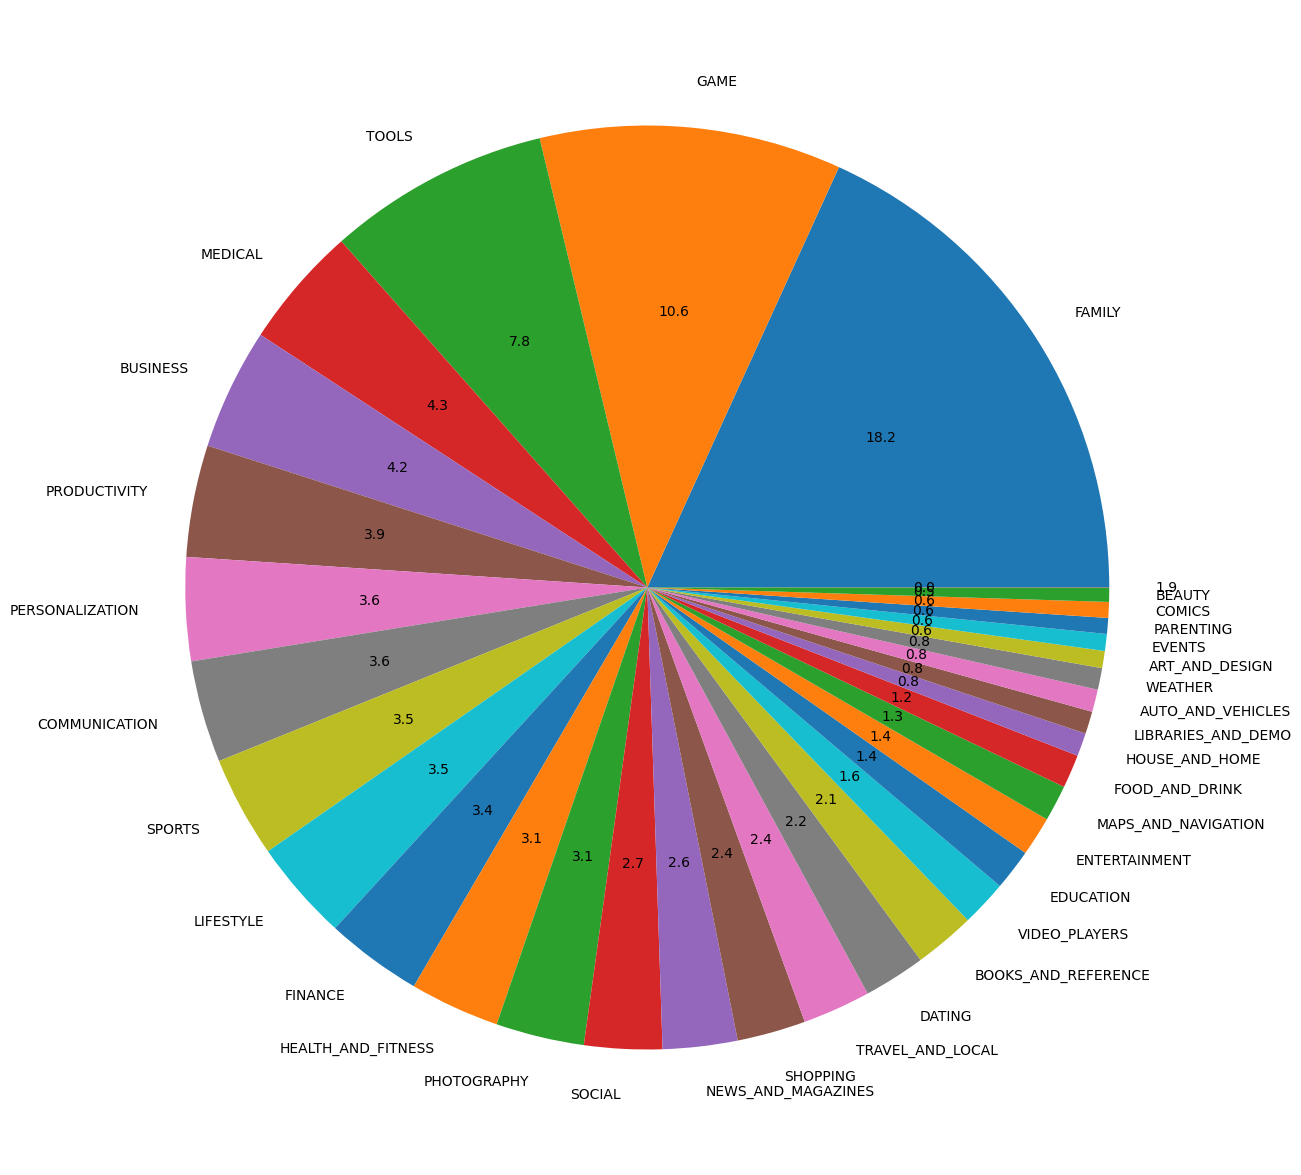

In [214]:
plt.figure(figsize=(15,15))
plt.pie(df['Category'].value_counts(),labels=df['Category'].value_counts().index,autopct='%1.1f')

In [205]:
df['Category'].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

<Axes: xlabel='Category', ylabel='count'>

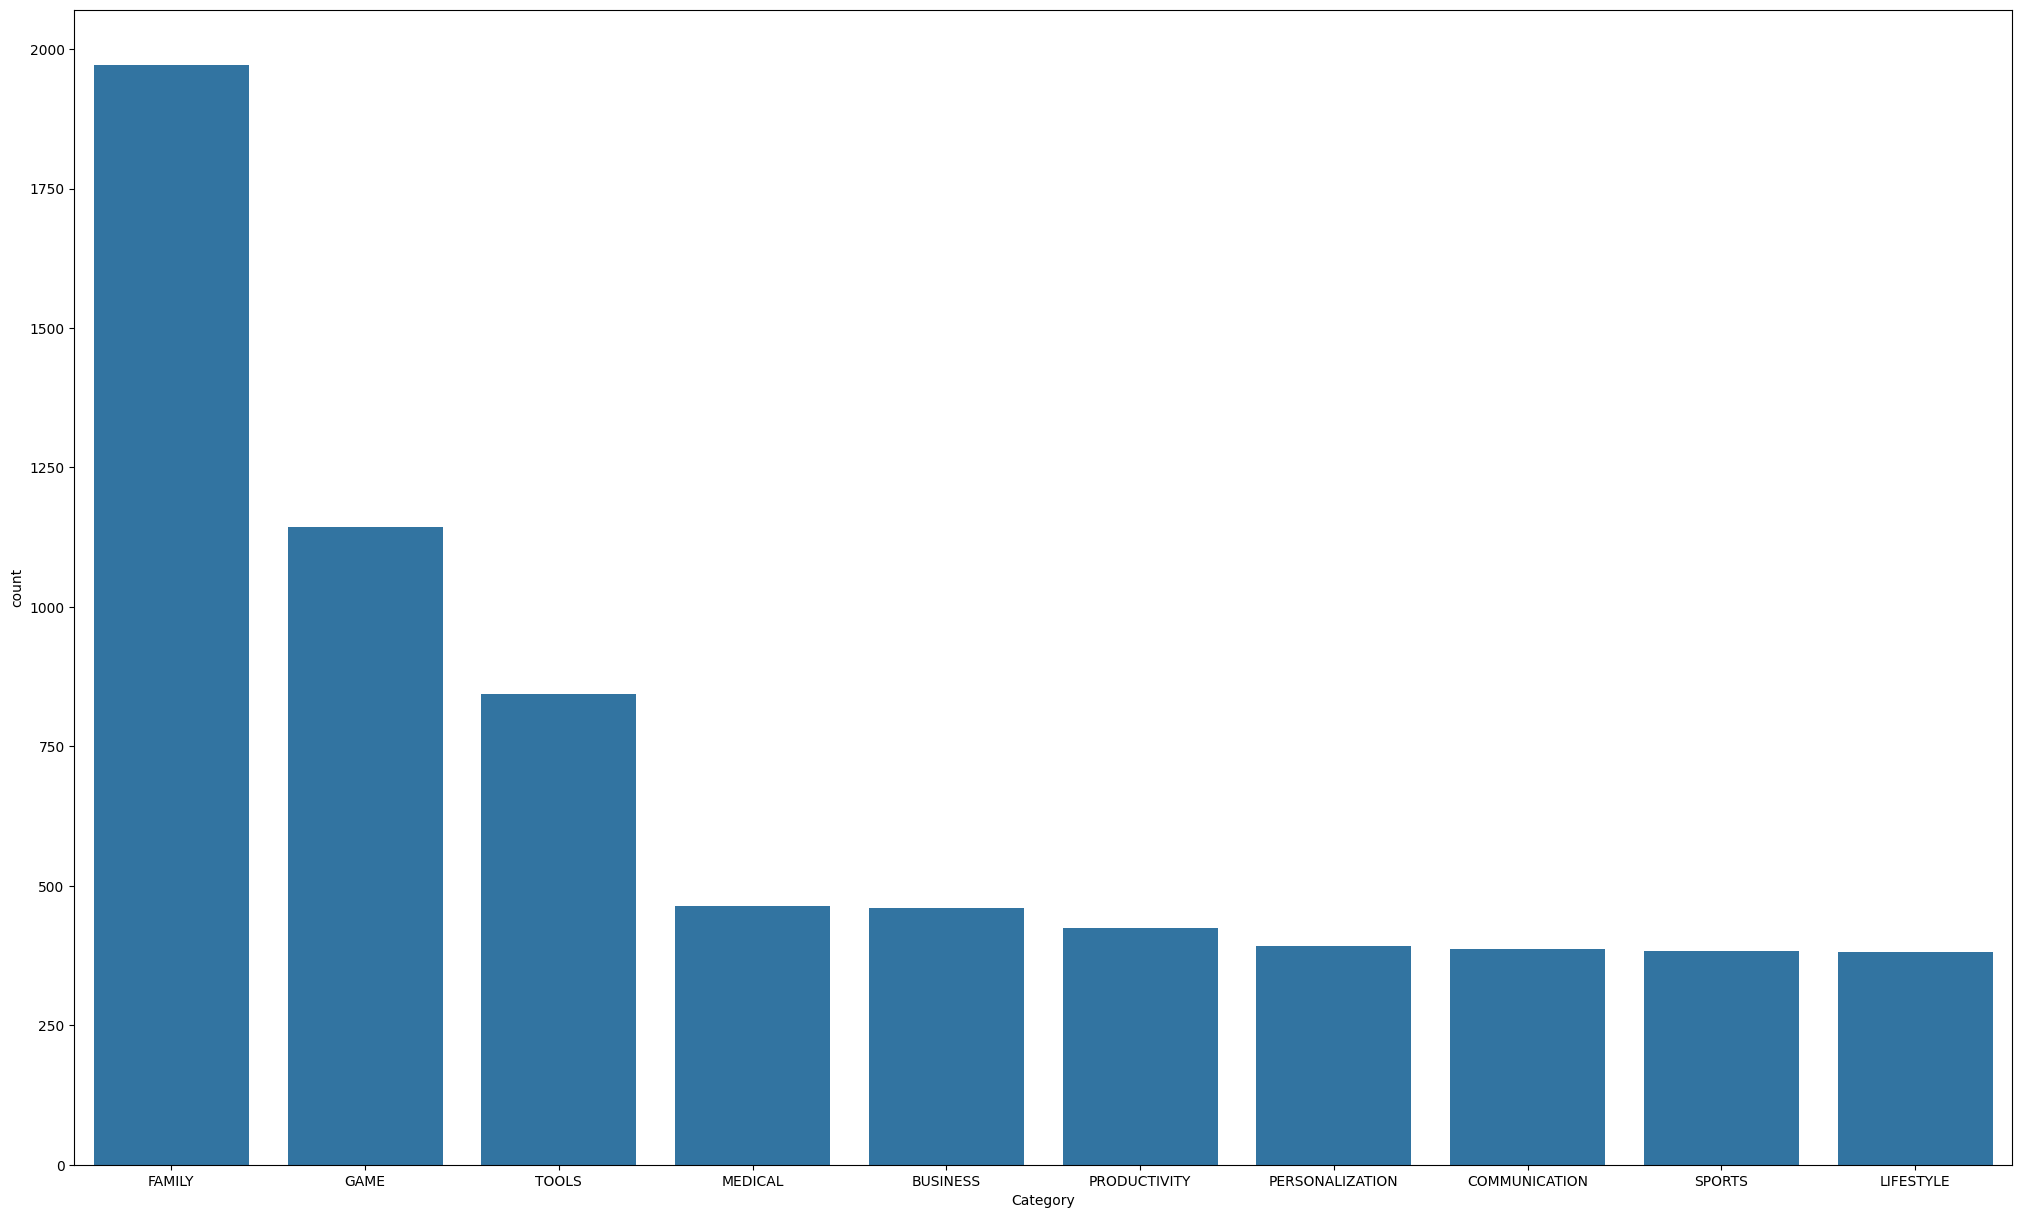

In [258]:
a=pd.DataFrame(df['Category'].value_counts())
plt.figure(figsize=(25,15))
sns.barplot(x='Category', y='count', data=a[:10])


In [246]:
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159,19000.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.900000,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.700000,87510,87000.0,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644,25000.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967,28000.0,100000,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.500000,38,53000.0,5000,Free,0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.000000,4,36000.0,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,4.191757,3,95000.0,1000,Free,0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.500000,114,NaN,1000,Free,0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,19,1,2015


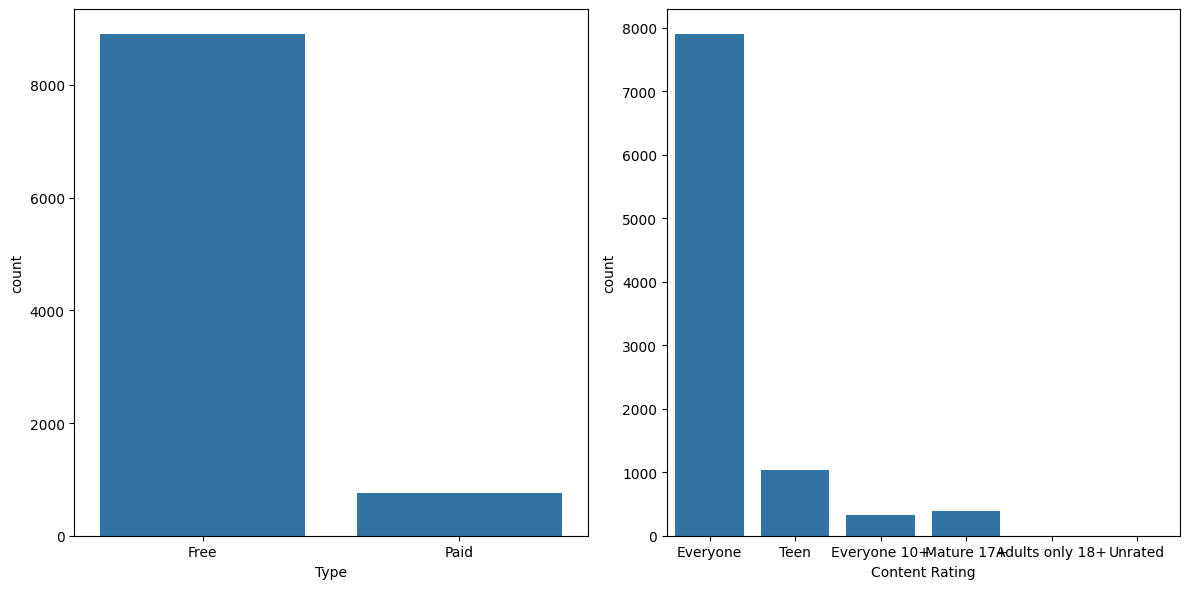

In [253]:
category=['Type','Content Rating']
plt.figure(figsize=(12,6))
for i in range(len(category)):
    plt.subplot(1,2,i+1)
    sns.countplot(x=df_copy[category[i]])
    plt.tight_layout()

In [266]:
df_copy['Installs']=df_copy['Installs'].astype('int')

/var/folders/_l/d3n9sd7d3y587cl59crr3lsc0000gn/T/ipykernel_86029/2612043900.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['Installs']=df_copy['Installs'].astype('int')


In [292]:
df_copy.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Day,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,87000.0,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,28000.0,100000,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,20,6,2018


In [281]:
#Finding the Category with larget number of installs
No_of_install=pd.DataFrame(df_copy.groupby('Category')['Installs'].sum())
No_of_install[No_of_install['Installs']==No_of_install['Installs'].max()]

,Installs
Category,
GAME,13878924415


In [293]:
# What are the top 5 most installed apps in each popular category
new_df = df_copy[['App','Category','Installs']]

In [325]:
No_of_install=No_of_install.sort_values('Installs')
top_category=No_of_install.tail(5)
Category=[col for col in top_category.index]
Category

['SOCIAL', 'PRODUCTIVITY', 'TOOLS', 'COMMUNICATION', 'GAME']

In [329]:
new_df

,App,Category,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,10000
1,Coloring book moana,ART_AND_DESIGN,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,5000000
3,Sketch - Draw & Paint,ART_AND_DESIGN,50000000
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,100000
...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,5000
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,100
10838,Parkinson Exercices FR,MEDICAL,1000
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,1000


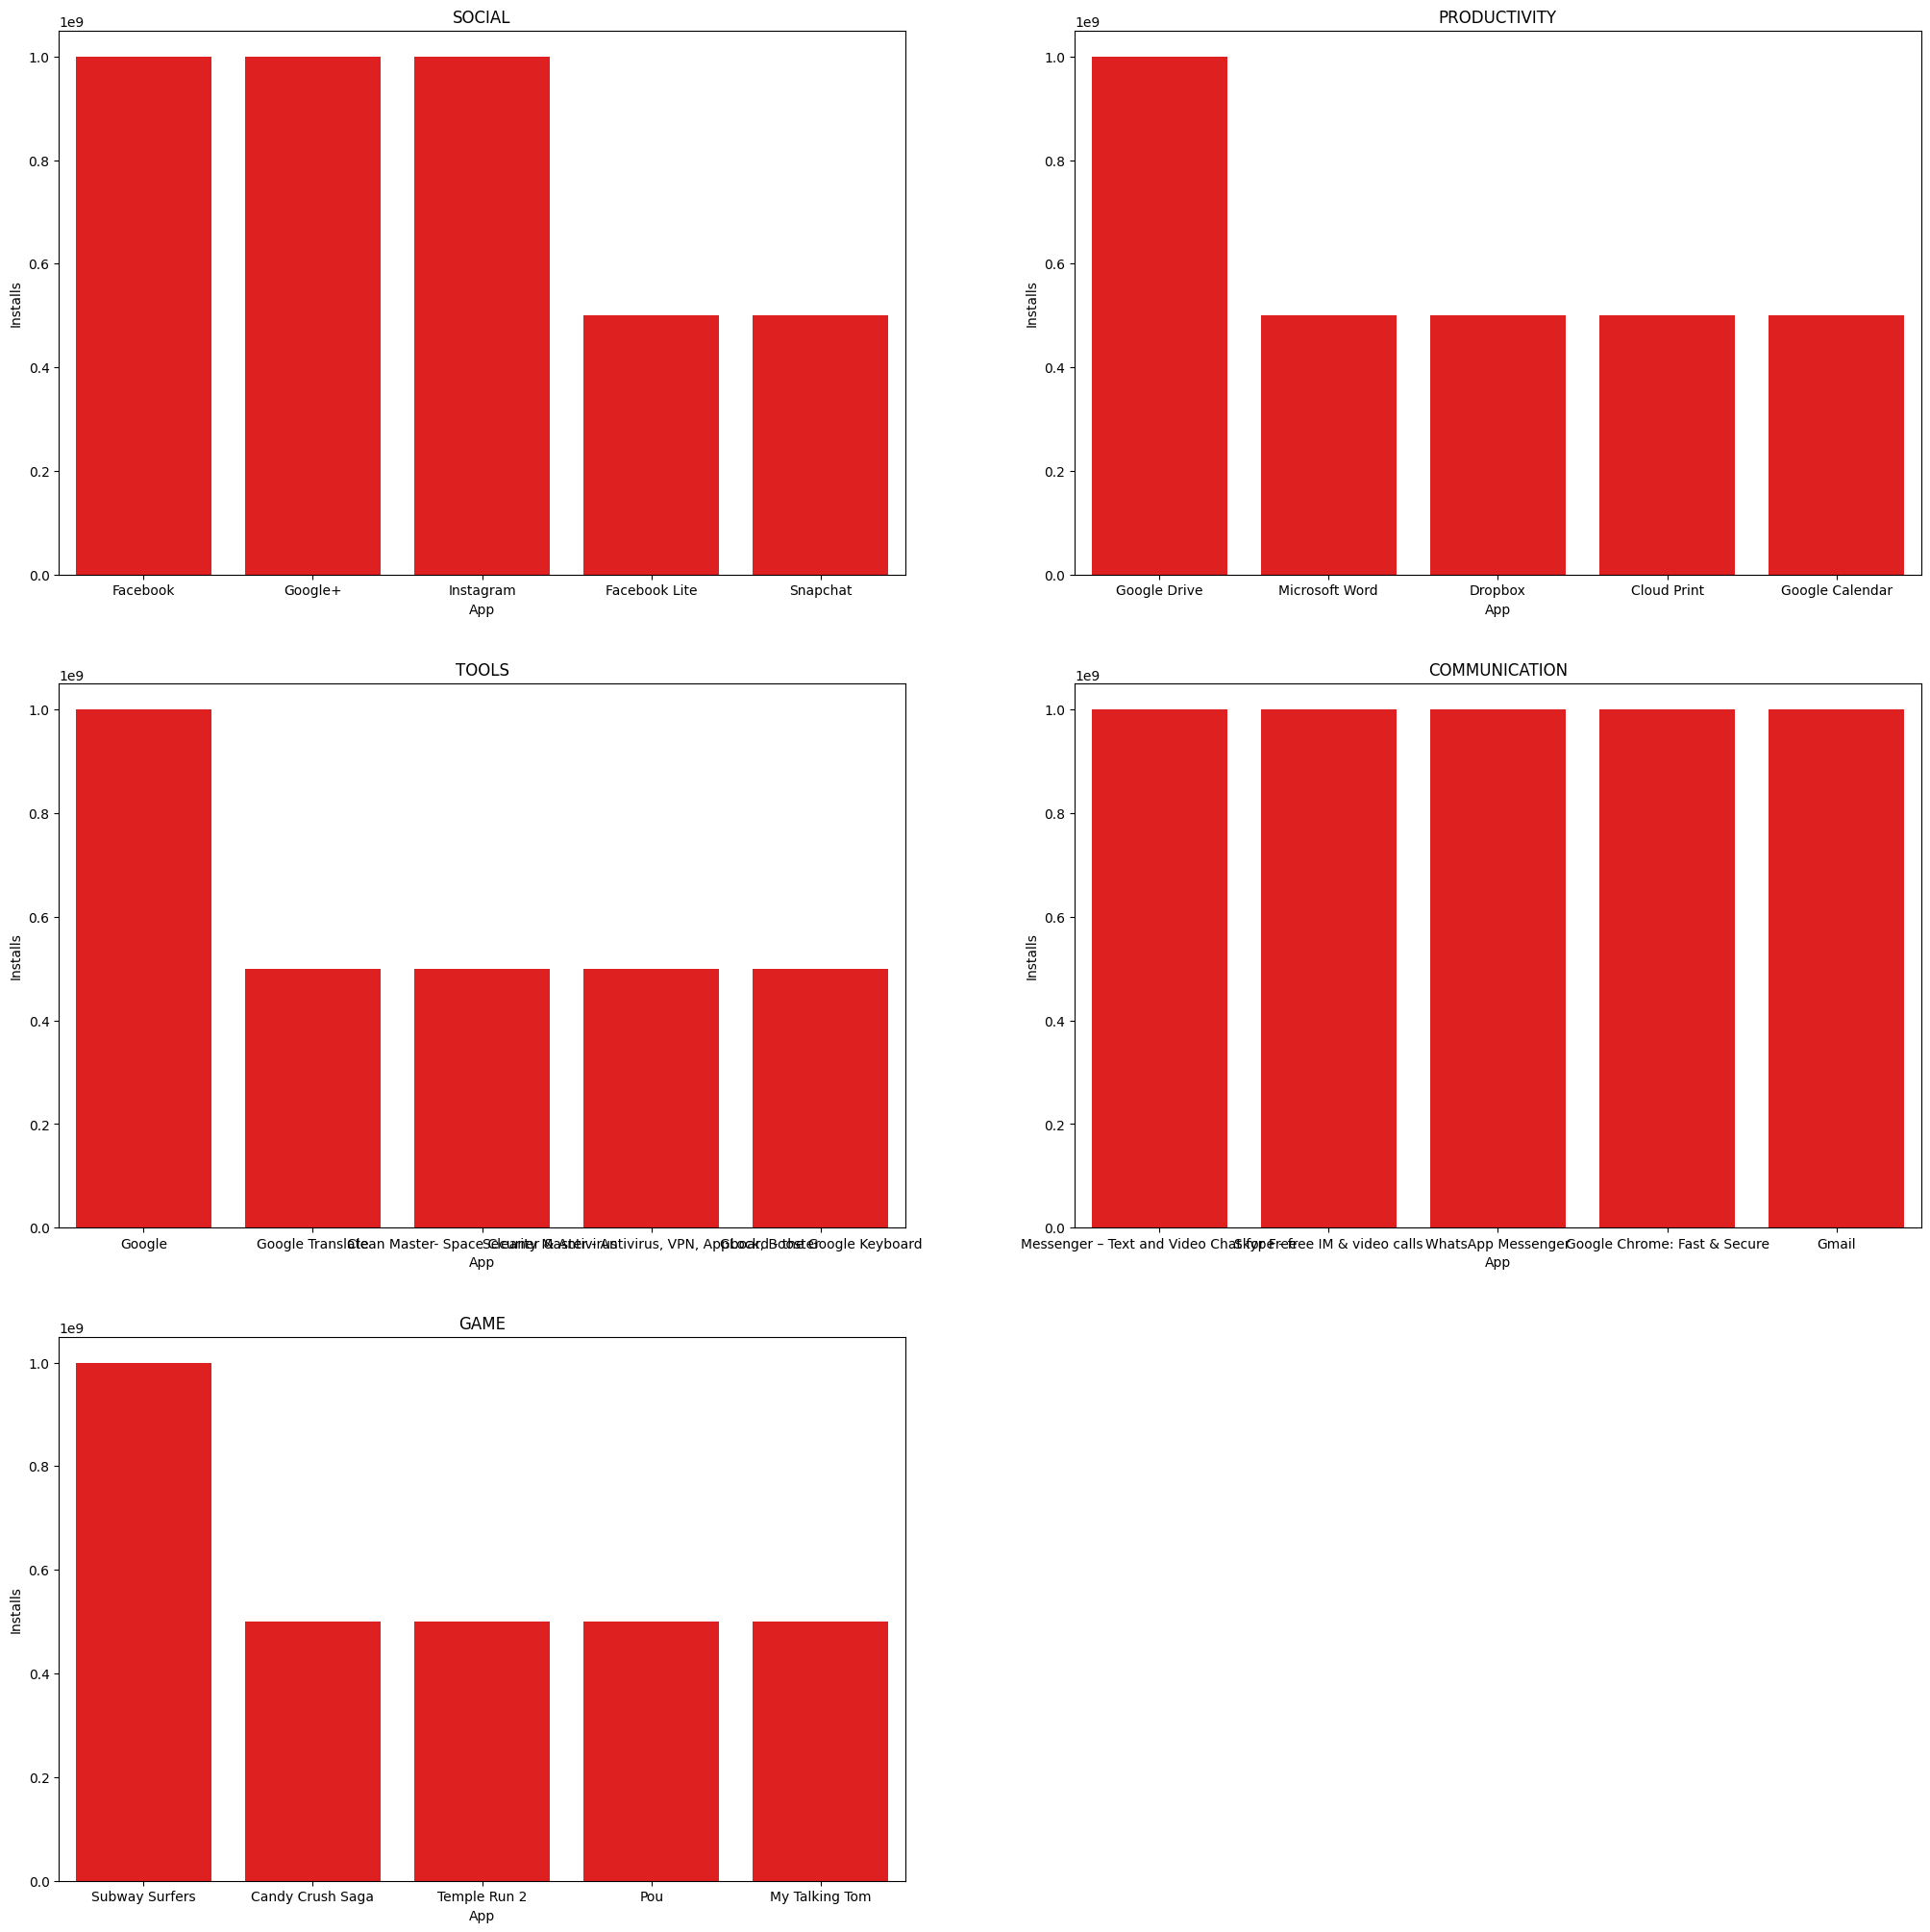

In [348]:
plt.figure(figsize=(25,25))
for i in range(len(Category)):
    cat_df=new_df[new_df['Category'] == Category[i]]
    cat_df=cat_df.sort_values(by='Installs',ascending=False)
    plt.subplot(3,2,i+1)
    plt.title(Category[i])
    sns.barplot(x='App',y='Installs',data=cat_df[:5],color='red')

In [364]:
top_app=df_copy[df_copy['Rating']>=5].sort_values(by="Installs",ascending=False)[['App','Rating','Installs']]
len(top_app)

271